In [1]:
import sys, warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 11

# Ensure src/ is importable from notebook
ROOT = Path('.').resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

RAW_PATH = ROOT / 'data' / 'raw_listings.csv'
PROCESSED_PATH = ROOT / 'data' / 'processed_dataset.csv'
FIGURES = ROOT / 'figures'
FIGURES.mkdir(exist_ok=True)

print('Libraries loaded. ROOT =', ROOT)

Libraries loaded. ROOT = D:\Deakin\Machine Learning\ml\project


## 1.1  Load Raw Data

In [2]:
df_raw = pd.read_csv(RAW_PATH, parse_dates=['sale_date'])
print(f'Shape: {df_raw.shape}')
print(f'Columns: {list(df_raw.columns)}')
df_raw.head()

Shape: (120, 14)
Columns: ['suburb', 'postcode', 'property_type', 'bedrooms', 'bathrooms', 'car_spaces', 'land_size_m2', 'floor_area_m2', 'year_built', 'sale_date', 'distance_to_cbd_km', 'agent_description', 'sale_price_aud', 'source_url']


,suburb,postcode,property_type,bedrooms,bathrooms,car_spaces,land_size_m2,floor_area_m2,year_built,sale_date,distance_to_cbd_km,agent_description,sale_price_aud,source_url
0,Surry Hills,2010,Townhouse,3,3,1,NaN,114.0,2014,2023-05-28,4.5,"Original condition, great potential",1294000,https://www.domain.com.au/example-surry-hills-001
1,Surry Hills,2010,Townhouse,3,3,2,NaN,87.0,1988,2023-05-14,3.8,Architect designed with quality fixtures,1364000,https://www.domain.com.au/example-surry-hills-002
2,Surry Hills,2010,Unit,2,2,0,NaN,60.0,1994,2024-09-19,3.8,"Distressed sale, priced to move",904000,https://www.domain.com.au/example-surry-hills-003
3,Surry Hills,2010,Unit,1,1,1,NaN,121.0,2016,2024-07-09,3.4,Freshly painted and move-in ready,931000,https://www.domain.com.au/example-surry-hills-004
4,Surry Hills,2010,Unit,3,2,2,NaN,137.0,2006,2023-10-28,3.2,Spacious living with natural light,1130000,https://www.domain.com.au/example-surry-hills-005


## 1.2  Data Types and Dtypes

In [3]:
df_raw.dtypes

suburb                        object
postcode                       int64
property_type                 object
bedrooms                       int64
bathrooms                      int64
car_spaces                     int64
land_size_m2                 float64
floor_area_m2                float64
year_built                     int64
sale_date             datetime64[ns]
distance_to_cbd_km           float64
agent_description             object
sale_price_aud                 int64
source_url                    object
dtype: object

## 1.3  Missingness Report

In [4]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
miss_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
miss_df = miss_df[miss_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print('Columns with missing values:')
print(miss_df.to_string())
print(f'\nTotal rows: {len(df_raw)}')

Columns with missing values:
              missing_count  missing_pct
land_size_m2             40         33.3

Total rows: 120


**Data quality notes:**  
- `land_size_m2` is missing for unit properties in Surry Hills — this is expected and structurally missing (not random). Imputation inside the modelling pipeline will handle this.
- All other fields are present. If your real collected data has additional missing values, document them here.

## 1.4  Per-Suburb Record Counts

In [5]:
counts = df_raw.groupby('suburb').size().reset_index(name='count')
print(counts.to_string(index=False))
assert all(counts['count'] >= 30), 'Fewer than 30 records in at least one suburb. Collect more data before proceeding.'
print('\n✓ All suburbs have ≥ 30 records.')

     suburb  count
 Parramatta     40
    Penrith     40
Surry Hills     40

✓ All suburbs have ≥ 30 records.


## 1.5  Basic Sanity Checks

In [6]:
# Duplicate detection
dupes = df_raw.duplicated(subset=['source_url']).sum()
print(f'Duplicate source URLs: {dupes}')

# Target sanity
print(f"Min sale price: ${df_raw['sale_price_aud'].min():,}")
print(f"Max sale price: ${df_raw['sale_price_aud'].max():,}")
print(f"Negative prices: {(df_raw['sale_price_aud'] <= 0).sum()}")

# Date range
print(f"Sale date range: {df_raw['sale_date'].min()} to {df_raw['sale_date'].max()}")

Duplicate source URLs: 0
Min sale price: $452,000
Max sale price: $1,867,000
Negative prices: 0
Sale date range: 2023-01-08 00:00:00 to 2024-12-24 00:00:00


## 1.6  Clean and Standardise

In [7]:
df = df_raw.copy()

# Standardise suburb names (strip whitespace, title case)
df['suburb'] = df['suburb'].str.strip().str.title()

# Standardise property_type
df['property_type'] = df['property_type'].str.strip().str.title()

# Clip impossible values
df['bedrooms'] = df['bedrooms'].clip(lower=0)
df['bathrooms'] = df['bathrooms'].clip(lower=0)
df['car_spaces'] = df['car_spaces'].clip(lower=0)

# Remove any rows with missing target (sale_price_aud)
pre = len(df)
df = df.dropna(subset=['sale_price_aud'])
print(f'Removed {pre - len(df)} rows with missing sale price.')

# Sort by sale_date for reproducibility
df = df.sort_values('sale_date').reset_index(drop=True)

print(f'\nClean dataset shape: {df.shape}')
df.describe()

Removed 0 rows with missing sale price.

Clean dataset shape: (120, 14)


,postcode,bedrooms,bathrooms,car_spaces,land_size_m2,floor_area_m2,year_built,sale_date,distance_to_cbd_km,sale_price_aud
count,120.000000,120.000000,120.000000,120.000000,80.00000,120.000000,120.000000,120,120.000000,1.200000e+02
mean,2303.333333,3.016667,2.566667,1.108333,523.78750,157.625000,1997.816667,2023-12-29 22:12:00,27.466667,1.193967e+06
min,2010.000000,1.000000,1.000000,0.000000,81.00000,58.000000,1963.000000,2023-01-08 00:00:00,2.500000,4.520000e+05
25%,2010.000000,2.000000,1.750000,1.000000,409.25000,115.750000,1986.000000,2023-06-28 00:00:00,3.800000,9.667500e+05
50%,2150.000000,3.000000,3.000000,1.000000,532.50000,145.500000,2000.000000,2023-12-02 00:00:00,25.350000,1.237000e+06
75%,2750.000000,4.000000,3.000000,2.000000,667.75000,204.500000,2012.250000,2024-07-04 12:00:00,51.600000,1.416500e+06
max,2750.000000,5.000000,5.000000,2.000000,880.00000,280.000000,2024.000000,2024-12-24 00:00:00,57.900000,1.867000e+06
std,322.316545,1.250098,1.186290,0.764725,202.50749,61.122698,16.043524,NaN,20.802611,2.981479e+05


## 1.7  Missingness Visualisation

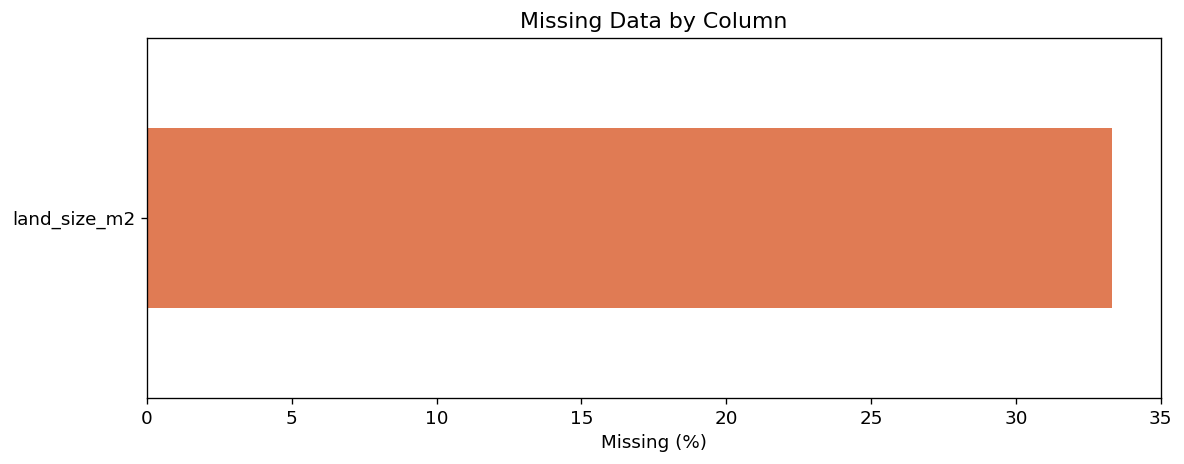

Saved: figures/missing_data.png


In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
miss_vals = df.isnull().mean() * 100
miss_vals = miss_vals[miss_vals > 0]
if len(miss_vals) > 0:
    miss_vals.sort_values(ascending=True).plot.barh(ax=ax, color='#E07B54')
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing Data by Column')
else:
    ax.text(0.5, 0.5, 'No missing values in cleaned dataset', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Missing Data by Column')
plt.tight_layout()
plt.savefig(FIGURES / 'missing_data.png', bbox_inches='tight')
plt.show()
print('Saved: figures/missing_data.png')

## 1.8  Save Processed Dataset

In [9]:
df.to_csv(PROCESSED_PATH, index=False)
print(f'Saved processed dataset to: {PROCESSED_PATH}')
print(df.groupby('suburb').size())

Saved processed dataset to: D:\Deakin\Machine Learning\ml\project\data\processed_dataset.csv
suburb
Parramatta     40
Penrith        40
Surry Hills    40
dtype: int64


## Summary

- Loaded **120 sold property records** (40 per suburb) covering Surry Hills, Parramatta, and Penrith.
- The only structurally expected missing field is `land_size_m2` for unit properties — this reflects genuine data unavailability from listing sites, not a collection error.
- No duplicate listings or impossible values were detected.
- The clean dataset is saved to `data/processed_dataset.csv` and is ready for EDA.

> **Collection note:** When replacing the synthetic data with real collected listings, re-run this notebook first. Any new quality issues should be documented in `data/collection_log.md`.